In [1]:
%matplotlib inline

In [2]:
import torch
import os

import pandas as pd
import numpy as np

from matplotlib import pyplot as plt

from torchcast.state_space import LogTransform
from torchcast.utils.datasets import load_air_quality_data
from torchcast.kalman_filter import KalmanFilter
from torchcast.utils.data import TimeSeriesDataset

from plotnine import facet_wrap

np.random.seed(2025-3-14)
torch.manual_seed(2025-3-14)

# Multivariate Forecasts: Beijing Multi-Site Air-Quality Data

We'll demonstrate several features of `torchcast` using a dataset from the [UCI Machine Learning Data Repository](https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data). It includes data on air pollutants and weather from 12 sites.

In [3]:
df_aq = load_air_quality_data('daily')

SPLIT_DT = np.datetime64('2016-02-22')
df_aq['dataset'] = np.where(df_aq['date'] > SPLIT_DT, 'val', 'train')
df_aq

,date,station,PM2p5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,dataset
0,2013-03-01,Aotizhongxin,7.125000,10.750000,11.708333,22.583333,429.166667,63.875000,1.391667,1026.875000,-18.745833,0.0,3.254167,train
1,2013-03-01,Changping,5.083333,18.958333,16.041667,15.333333,387.500000,77.791667,0.812500,1023.858333,-19.583333,0.0,2.133333,train
2,2013-03-01,Dingling,6.375000,6.409091,3.000000,2.625000,204.166667,81.958333,0.812500,1023.858333,-19.583333,0.0,2.133333,train
3,2013-03-01,Dongsi,6.416667,9.875000,8.478261,28.521739,395.652174,72.782609,1.325000,1028.783333,-21.466667,0.0,3.308333,train
4,2013-03-01,Guanyuan,7.541667,11.666667,8.500000,28.500000,400.000000,63.166667,1.391667,1026.875000,-18.745833,0.0,3.254167,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17527,2017-02-28,Nongzhanguan,17.523810,24.739130,7.347826,35.652174,526.086957,56.086957,10.958333,1014.887500,-12.783333,0.0,2.058333,val
17528,2017-02-28,Shunyi,20.708333,28.500000,7.125000,39.666667,579.166667,57.291667,9.250000,1015.550000,-10.429167,0.0,2.025000,val
17529,2017-02-28,Tiantan,14.875000,32.708333,6.454545,42.904762,540.909091,57.600000,10.958333,1014.887500,-12.783333,0.0,2.058333,val
17530,2017-02-28,Wanliu,9.958333,25.583333,7.458333,40.916667,479.166667,54.791667,10.516667,1013.345833,-12.266667,0.0,1.800000,val


## Univariate Forecasts

Let's build a model to predict total particulate-matter (PM2.5 and PM10). 

First, we'll make our target the sum of these two types. We'll log-transform since this is strictly positive.

In [4]:
df_aq['PM'] = df_aq['PM10'] + df_aq['PM2p5'] 
df_aq['PM_log10'] = np.log10(df_aq['PM']) 

In [5]:
# create our dataset:
dataset_pm = TimeSeriesDataset.from_dataframe(
    dataframe=df_aq,
    dt_unit='D',
    measure_colnames=['PM_log10'],
    group_colname='station', 
    time_colname='date'
)
dataset_pm_train, _ = dataset_pm.train_val_split(dt=SPLIT_DT)

In [6]:
# specify our model:
from torchcast.process import LocalTrend, Season

kf_pm = KalmanFilter(
    measures=['PM_log10'], 
    processes=[
        LocalTrend(id='trend'),
        Season(
            id='day_in_year', 
            period=365.25, 
            dt_unit='D', 
            K=4,
            fixed=True
        ),
        Season(
            id='day_in_week', 
            period=7, 
            dt_unit='D', 
            K=2,
            fixed=True
        )
    ],
)

In [7]:
# fit it:
kf_pm.fit(
    dataset_pm_train.tensors[0],
    start_offsets=dataset_pm_train.start_datetimes,
    n_step=5, every_step=False,
)

For measure PM_log10, setting initial value by setting 'trend.position' to 2.1530


0it [00:00, ?it/s]

KalmanFilter(
  (measure_covariance): Covariance()
  (processes): ModuleDict(
    (trend): LocalTrend(id='trend', measure='PM_log10')
    (day_in_year): Season(id='day_in_year', measure='PM_log10')
    (day_in_week): Season(id='day_in_week', measure='PM_log10')
  )
  (process_covariance): Covariance()
  (initial_covariance): Covariance()
)

<div class="admonition note">
<div class="admonition-title">The `n_step` argument</div>

When fitting our model, we use the `n_step` argument to improve longer-range forecasts. We know we will be using our model to forecast weeks/months into the future, so we 'encourage' the model to get good at this task by optimizing for 5-step-ahead forecasts (rather than the traditional 1-step-ahead forecasts) in training. 

This simple strategy can often dramatically improve the quality of long-range forecasts; and paired with the `every_step=False` setting, does not cause an increase in training-time.
</div>

Let's see how our forecasts look:

Our model's predictions are on the log scale. To get forecasts on the original scale, we pass `transform=LogTransform(base=10)` to `to_dataframe()`. This correctly back-transforms the mean (i.e. the mean of $10^{Y}$, which is larger than $10$ raised to the mean of $Y$) as well as the prediction intervals.

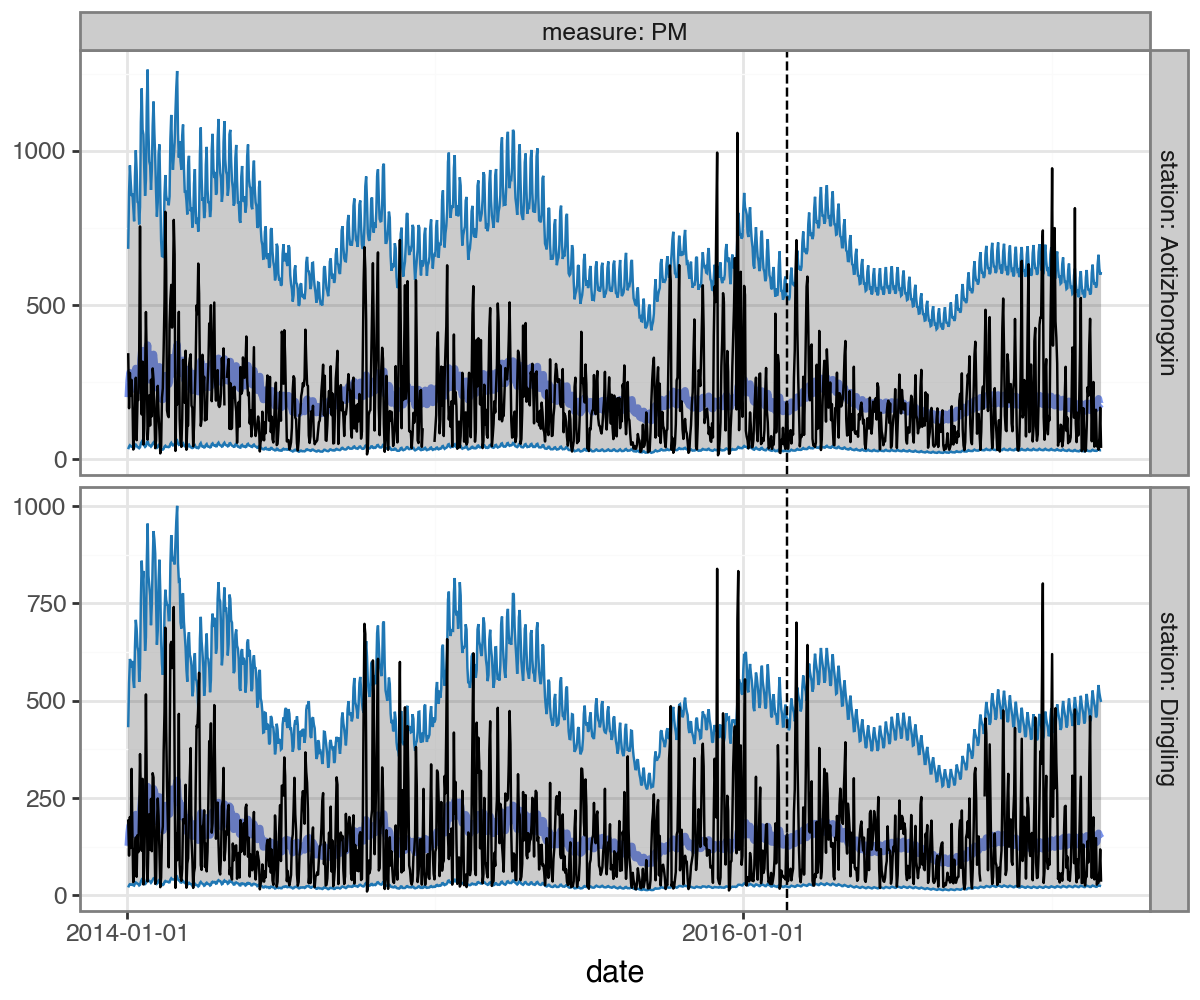

In [8]:
# generate forecasts:
forecast = kf_pm(
        dataset_pm_train.tensors[0],
        start_offsets=dataset_pm_train.start_datetimes,
        out_timesteps=dataset_pm.tensors[0].shape[1]
)

# convert to dataframe, back-transform:
df_uv_pred = (forecast
             .set_metadata(group_colname='station', time_colname='date')
             .to_dataframe(dataset_pm, transform=LogTransform(base=10))
             .assign(measure=lambda df: df['measure'].str.replace('_log10', '')))

# plot:
forecast.plot(
    df_uv_pred.query("date>'2014-01-01'").query("station.isin(['Aotizhongxin', 'Dingling'])"), 
    max_num_groups=2, 
    split_dt=SPLIT_DT, 
    figure_size=(6,5)
) #+ scale_y_log10()

## Multivariate Forecasts

Can we improve our model by splitting the pollutant we are forecasting into its two types (2.5 and 10), and modeling them in a multivariate manner?

In [9]:
# create a dataset:
df_aq['PM10_log10'] = np.log10(df_aq['PM10'])
df_aq['PM2p5_log10'] = np.log10(df_aq['PM2p5'])
dataset_pm_mv = TimeSeriesDataset.from_dataframe(
    dataframe=df_aq,
    dt_unit='D',
    measure_colnames=['PM10_log10','PM2p5_log10'],
    group_colname='station', 
    time_colname='date'
)
dataset_pm_mv_train, _ = dataset_pm_mv.train_val_split(dt=SPLIT_DT)

# create a model:
_processes = []
for m in dataset_pm_mv.measures[0]:
    _processes.extend([
        LocalTrend(id=f'{m}_trend', measure=m),
        Season(
            id=f'{m}_day_in_year', 
            period=365.25, 
            dt_unit='D', 
            K=4, 
            measure=m, 
            fixed=True
        ),
        
        Season(
            id=f'{m}_day_in_week', 
            period=7, 
            dt_unit='D', 
            K=2,
            measure=m,
            fixed=True
        )
    ])
kf_pm_mv = KalmanFilter(
    measures=dataset_pm_mv.measures[0], 
    processes=_processes,
)

# fit:
kf_pm_mv.fit(
    dataset_pm_mv_train.tensors[0],
    start_offsets=dataset_pm_mv_train.start_datetimes,
    n_step=5, every_step=False,
)

For measure PM10_log10, setting initial value by setting 'PM10_log10_trend.position' to 1.9197
For measure PM2p5_log10, setting initial value by setting 'PM2p5_log10_trend.position' to 1.7518


0it [00:00, ?it/s]

KalmanFilter(
  (measure_covariance): Covariance()
  (processes): ModuleDict(
    (PM10_log10_trend): LocalTrend(id='PM10_log10_trend', measure='PM10_log10')
    (PM10_log10_day_in_year): Season(id='PM10_log10_day_in_year', measure='PM10_log10')
    (PM10_log10_day_in_week): Season(id='PM10_log10_day_in_week', measure='PM10_log10')
    (PM2p5_log10_trend): LocalTrend(id='PM2p5_log10_trend', measure='PM2p5_log10')
    (PM2p5_log10_day_in_year): Season(id='PM2p5_log10_day_in_year', measure='PM2p5_log10')
    (PM2p5_log10_day_in_week): Season(id='PM2p5_log10_day_in_week', measure='PM2p5_log10')
  )
  (process_covariance): Covariance()
  (initial_covariance): Covariance()
)

Generate our forecasts as before:

In [10]:
with torch.no_grad():
    forecast_mv = kf_pm_mv(
        dataset_pm_mv_train.tensors[0],
        start_offsets=dataset_pm_mv_train.start_datetimes,
        out_timesteps=dataset_pm_mv.num_timesteps # <--- how we ask it to forecast past original times
    )
forecast_mv.means.shape

torch.Size([12, 1461, 2])

Subsetting to groups: ['Aotizhongxin', 'Dingling']


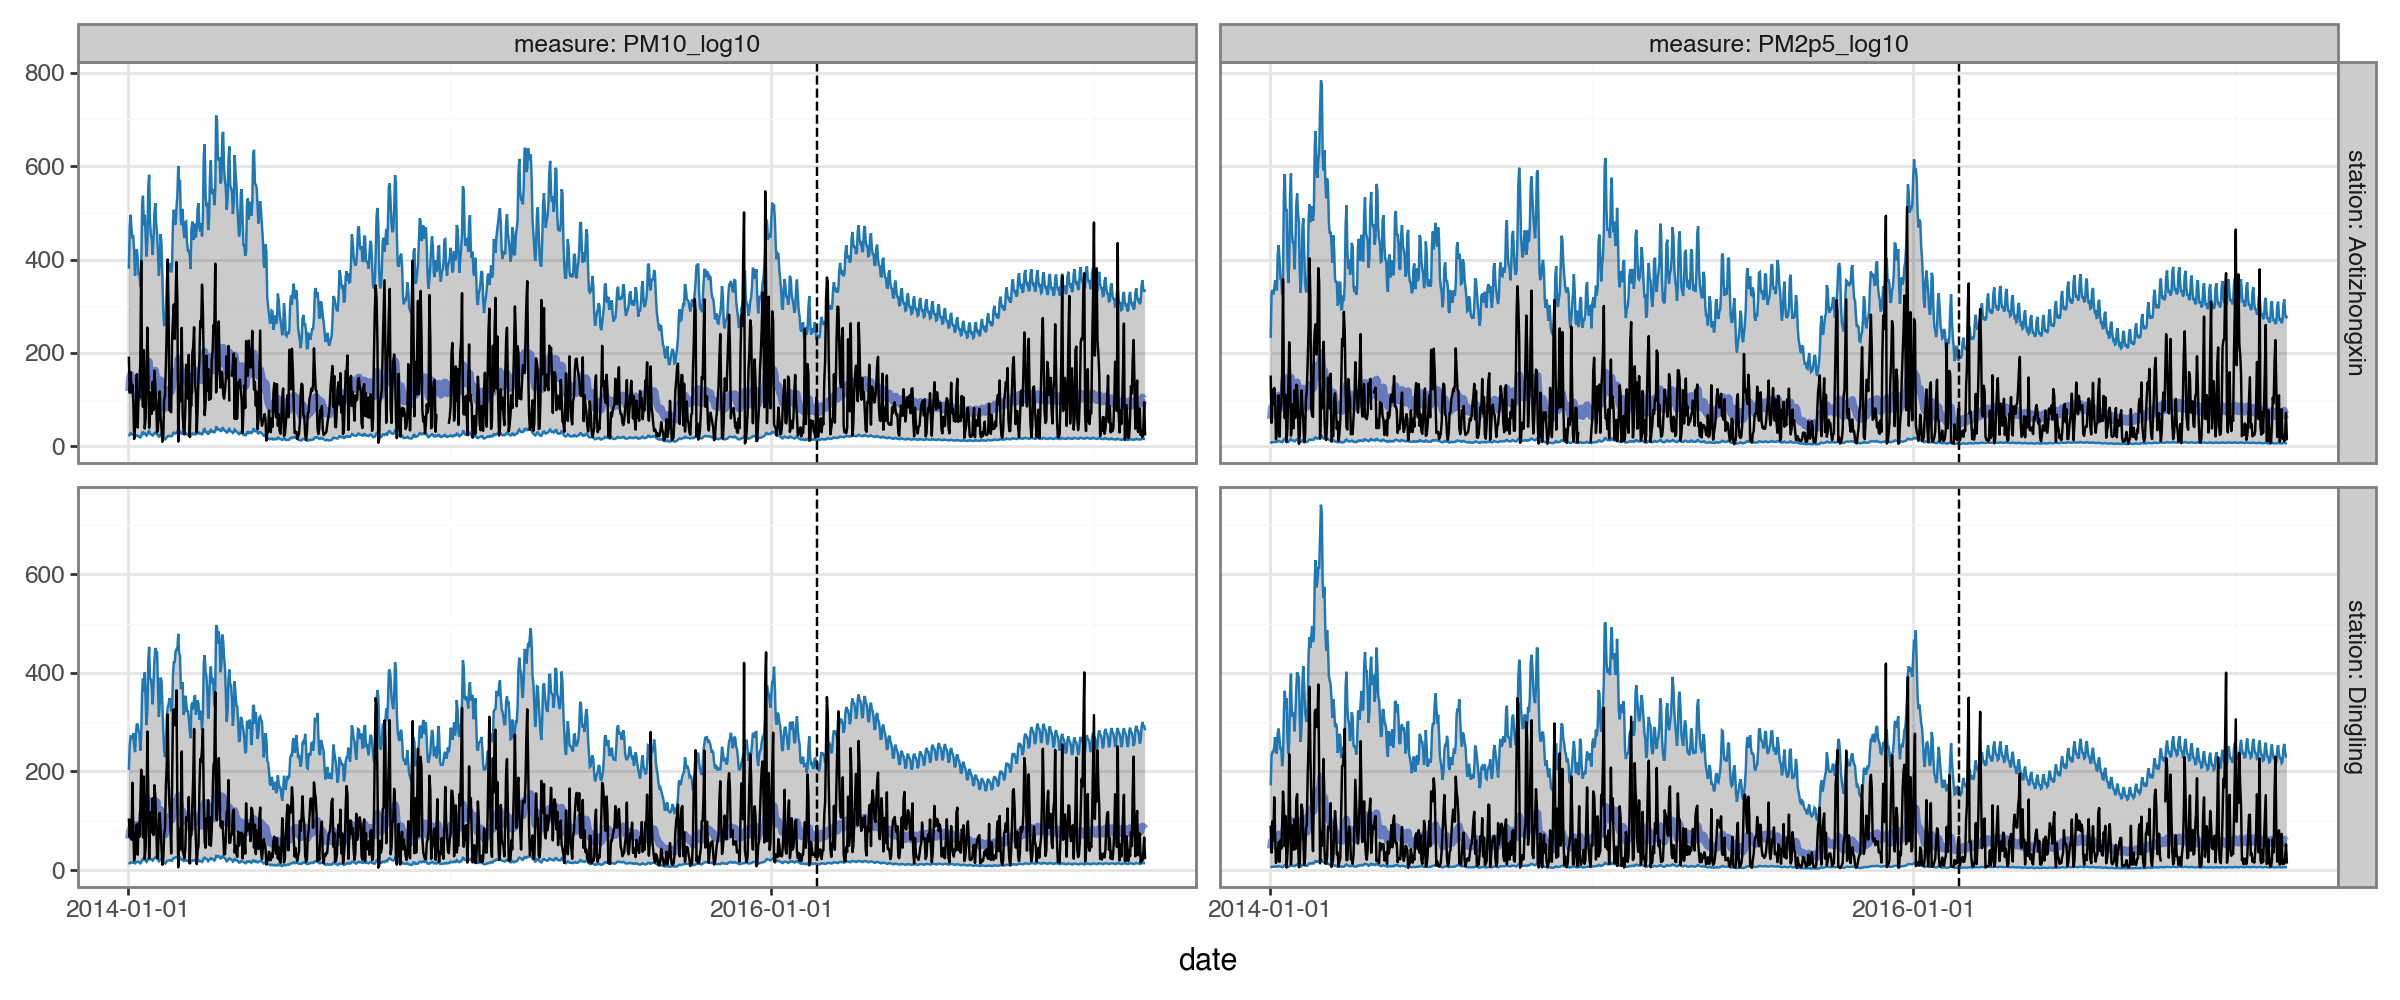

In [11]:
forecast_mv.plot(
    forecast_mv
    .set_metadata(group_colname='station', time_colname='date')
    .to_dataframe(dataset_pm_mv, transform=LogTransform(base=10))
    .query("date>'2014-01-01'"),
    max_num_groups=2, 
    split_dt=SPLIT_DT, 
)

At this point, though, we run into a problem: we we have forecasts for both PM2.5 and PM10, but we ultimately want a forecast for their *sum*. With untransformed data, we could take advantage of the fact that [sum of correlated normals is still normal](https://en.wikipedia.org/wiki/Sum_of_normally_distributed_random_variables#Correlated_random_variables); but we have log-transformed our measures. This seems like it was the right choice (i.e. our residuals look reasonably normal and i.i.d):

Subsetting to groups: ['Wanliu']


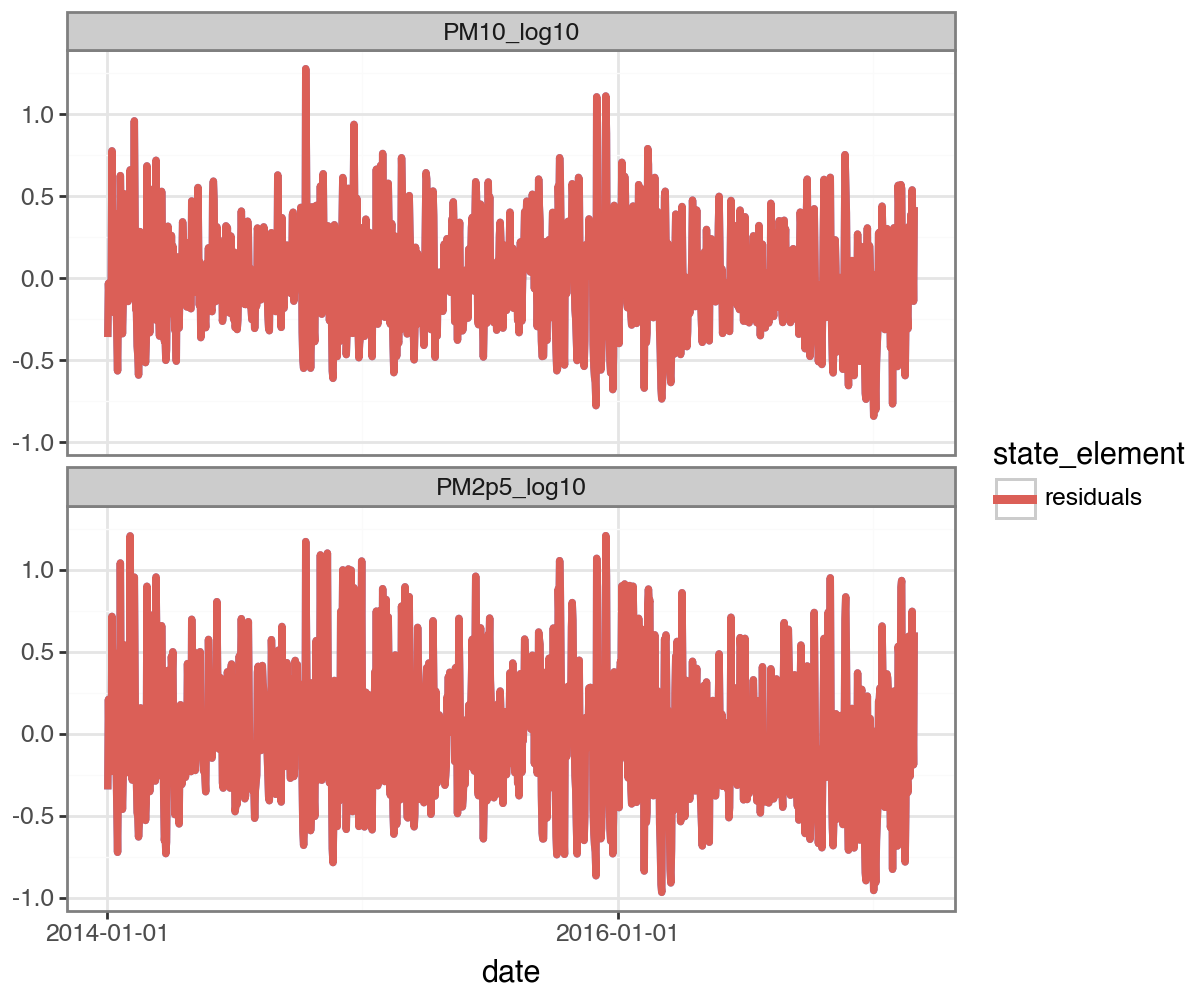

In [12]:
forecast_mv.plot(
    forecast_mv
    .to_dataframe(dataset_pm_mv, type='components')
    .query("process=='residuals'")
    .query("date>'2014-01-01'"),
    figure_size=(6,5)
) + facet_wrap('measure', ncol=1)

In this case, we can't take the sum of our forecasts to get the forecast of the sum, and [there's no simple closed-form expression for the sum of lognormals](https://scholar.google.com/scholar?hl=en&as_sdt=0%2C14&q=SUMS+OF+LOGNORMALS&btnG=).

Instead, we can use the `derived` argument to `to_dataframe()`. This lets us specify a quantity computed from multiple measures: here, the sum of PM10 and PM2.5 on the original scale. Under the hood, `torchcast` draws samples from the joint forecast distribution -- accounting for the correlation between the two measures -- back-transforms them (via `transform`), sums them, and then summarizes across samples to get the mean and prediction intervals. (The same function is applied to the actuals, giving the actual total.)

In [13]:
df_mv_pred = (forecast_mv
              .to_dataframe(
                  dataset_pm_mv,
                  transform=LogTransform(base=10),
                  derived={'PM': lambda s: s['PM10_log10'] + s['PM2p5_log10']}
              )
              .query("measure == 'PM'"))
df_mv_pred.head()

,mean,lower,upper,actual,station,date,measure
0,99.939072,7.254608,512.916138,17.875002,Aotizhongxin,2013-03-01,PM
1,69.378296,6.007150,292.136749,72.833328,Aotizhongxin,2013-03-02,PM
2,169.552658,8.800461,891.541931,197.458328,Aotizhongxin,2013-03-03,PM
3,197.521729,10.819192,980.176208,67.291672,Aotizhongxin,2013-03-04,PM
4,106.563248,7.562123,480.392212,332.666656,Aotizhongxin,2013-03-05,PM


## Evaluating Performance

In [14]:
def get_station_error(df: pd.DataFrame, pred_colname: str = 'mean', actual_colname: str = 'actual') -> pd.DataFrame:
    return (df
             .assign(sq_error=lambda df: (df[pred_colname] - df[actual_colname]) ** 2)
             .groupby(['station'])
             ['sq_error'].mean()
             .reset_index()
             .assign(rmse= lambda df: df['sq_error'] ** .5))

def agg_within_group_err(df: pd.DataFrame, error_col : str = 'rmse', group_col: str = 'station') -> pd.DataFrame:
    df = df.copy(deep=False)
    df['error_norm'] = df[error_col] - df.groupby(group_col)[error_col].transform('mean')
    return df.groupby('model').agg(**{error_col : (error_col, 'mean'), 'sem' : ('error_norm', 'sem')})

In [15]:
df_fct_err = pd.concat([
            df_uv_pred
             .loc[lambda df: df['date'] > SPLIT_DT,:]
             .pipe(get_station_error)
             .assign(model='univariate')
            ,
            df_mv_pred
             .loc[lambda df: df['date'] > SPLIT_DT,:]
             .pipe(get_station_error)
             .assign(model='multivariate')
]).reset_index(drop=True)
df_fct_err.sort_values('station').tail(6)

,station,sq_error,rmse,model
21,Tiantan,21993.816406,148.303116,multivariate
9,Tiantan,21812.578125,147.690826,univariate
22,Wanliu,19969.923828,141.314987,multivariate
10,Wanliu,19787.677734,140.668686,univariate
11,Wanshouxigong,23153.716797,152.163452,univariate
23,Wanshouxigong,23239.757812,152.445923,multivariate


Below we aggregate the performance across stations (controlling for within-station variation to reduce noise).

We see that the two approaches perform about the same: forecasting the total directly with a univariate model is, if anything, slightly better than summing the two multivariate forecasts. We'll look at when a multivariate model *does* help below.

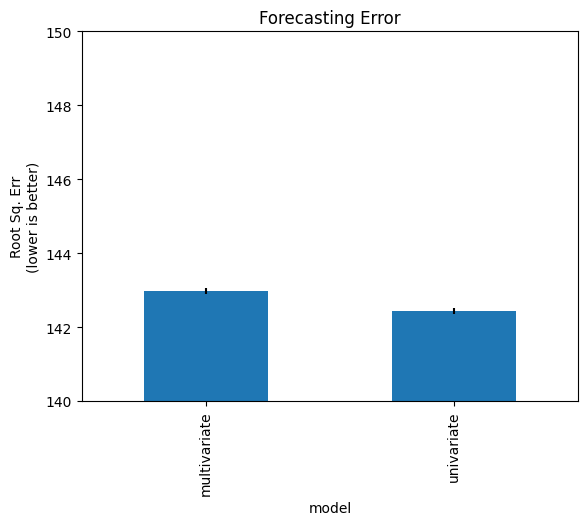

In [16]:
df_fct_err_agg = agg_within_group_err(df_fct_err)

# https://chris-said.io/2014/12/01/independent-t-tests-and-the-83-confidence-interval-a-useful-trick-for-eyeballing-your-data/
from scipy import stats
sem_multi = -stats.norm.ppf((1 - .83) / 2)

df_fct_err_agg['rmse'].plot(
    kind='bar', 
    yerr=df_fct_err_agg['sem'] * sem_multi, 
    ylabel="Root Sq. Err\n(lower is better)", 
    title="Forecasting Error",
    ylim=(140,150)
)
plt.show()

### Expanding Window Approach

One limitation to evaluating performance with a single train/val split-date is we run the risk that our results are sensitive to that particular split.

An alternative approach is an "expanding window": we loop over the series, training on increasingly long sections, and forecasting on a fixed period beyond this. For short series, it might make sense to retrain on each iteration. 

However for longer series, to speed up the process, we might want to simply use a particular date-range for training, then do our expanding window procedure on the held out remainder. (This is challenging in many forecasting APIs because they do not allow passing new series -- or extensions of the trained series -- at inference time, but instead require retraining.) 

In `torchcast`, it's easy to apply an expanding-window method with the `n_step` argument, avoiding the need for any refit -> forecast external loop.

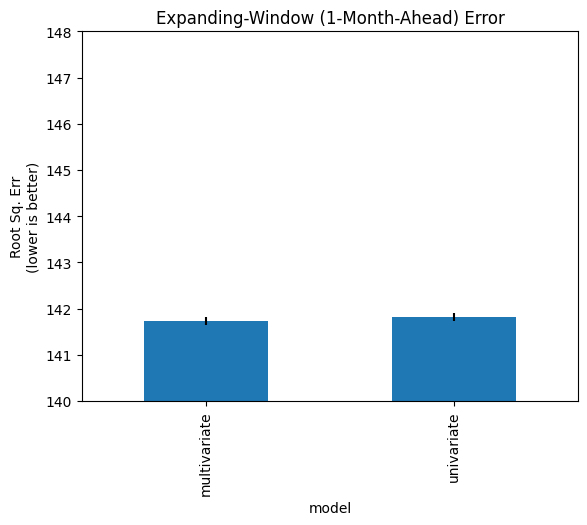

In [17]:
with torch.no_grad():
    one_mo_uv = kf_pm(
        dataset_pm.tensors[0],
        start_offsets=dataset_pm.start_datetimes,
        n_step=30
    )
    one_mo_mv = kf_pm_mv(
        dataset_pm_mv.tensors[0],
        start_offsets=dataset_pm_mv.start_datetimes,
        n_step=30
    )
    
df_backtest_err1mo = pd.concat([

    one_mo_uv
    .to_dataframe(dataset_pm, time_colname='date', group_colname='station', transform=LogTransform(base=10))
    .loc[lambda df: df['date'] > SPLIT_DT, :]
    .pipe(get_station_error)
    .assign(model='univariate')
    ,

    one_mo_mv
    .to_dataframe(
        dataset_pm_mv,
        time_colname='date',
        group_colname='station',
        transform=LogTransform(base=10),
        derived={'PM': lambda s: s['PM10_log10'] + s['PM2p5_log10']}
    )
    .query("measure == 'PM'")
    .loc[lambda df: df['date'] > SPLIT_DT,:]
    .pipe(get_station_error)
    .assign(model='multivariate')
])

df_backtest1mo_err_agg = agg_within_group_err(df_backtest_err1mo)

df_backtest1mo_err_agg['rmse'].plot(
    kind='bar', 
    yerr=df_backtest1mo_err_agg['sem'], 
    ylabel="Root Sq. Err\n(lower is better)", 
    title="Expanding-Window (1-Month-Ahead) Error",
    ylim=(140,148)
)
plt.show()

## When Does a Multivariate Model Help?

So far, modeling PM2.5 and PM10 jointly hasn't improved our forecasts. That's not because the two are unrelated: they're strongly correlated. But *how* they're correlated matters. Let's look at the correlation of the two measures' day-to-day fluctuations (the "measurement noise") in our fitted model:

In [18]:
from torchcast.covariance import cov2corr

with torch.no_grad():
    print(cov2corr(kf_pm_mv.measure_covariance({}, num_groups=1, num_times=1)[0, 0]))

tensor([[1.0000, 0.9103],
        [0.9103, 1.0000]])


Most of the co-movement of PM2.5 and PM10 is in these day-to-day fluctuations. Those are unpredictable in advance, so knowing that they're correlated doesn't help a forecast of either pollutant (or their total).

But it helps a lot when we observe one pollutant and not the other. For example, suppose the PM2.5 sensors at every station went down for two months, while PM10 kept reporting. A univariate PM2.5 model can only forecast through the outage. The multivariate model's predictions include the full covariance of the two measures, so on each day we can *condition* on the observed PM10.

First, a univariate model for PM2.5 alone, for comparison:

In [19]:
dataset_pm25 = TimeSeriesDataset.from_dataframe(
    dataframe=df_aq,
    dt_unit='D',
    measure_colnames=['PM2p5_log10'],
    group_colname='station',
    time_colname='date'
)
dataset_pm25_train, _ = dataset_pm25.train_val_split(dt=SPLIT_DT)

kf_pm25 = KalmanFilter(
    measures=['PM2p5_log10'],
    processes=[
        LocalTrend(id='trend'),
        Season(id='day_in_year', period=365.25, dt_unit='D', K=4, fixed=True),
        Season(id='day_in_week', period=7, dt_unit='D', K=2, fixed=True)
    ],
)
kf_pm25.fit(
    dataset_pm25_train.tensors[0],
    start_offsets=dataset_pm25_train.start_datetimes,
    n_step=5, every_step=False,
)

For measure PM2p5_log10, setting initial value by setting 'trend.position' to 1.7518


0it [00:00, ?it/s]

KalmanFilter(
  (measure_covariance): Covariance()
  (processes): ModuleDict(
    (trend): LocalTrend(id='trend', measure='PM2p5_log10')
    (day_in_year): Season(id='day_in_year', measure='PM2p5_log10')
    (day_in_week): Season(id='day_in_week', measure='PM2p5_log10')
  )
  (process_covariance): Covariance()
  (initial_covariance): Covariance()
)

Now we simulate the outage, by hiding PM2.5 for 60 days. For the multivariate model, we condition each day's (log-scale) PM2.5 prediction on that day's PM10, using the standard formula for a conditional normal distribution, then back-transform.

In [20]:
OUTAGE_START = np.datetime64('2016-11-01')
OUTAGE_END = OUTAGE_START + np.timedelta64(60, 'D')
in_outage = torch.as_tensor((dataset_pm_mv.times() >= OUTAGE_START) & (dataset_pm_mv.times() < OUTAGE_END))

# hide PM2.5 during the outage:
y_mv = dataset_pm_mv.tensors[0].clone()
y_mv[..., 1][in_outage] = float('nan')
y_uv = dataset_pm25.tensors[0].clone()
y_uv[..., 0][in_outage] = float('nan')

with torch.no_grad():
    pred_uv = kf_pm25(y_uv, start_offsets=dataset_pm25.start_datetimes)
    pred_mv = kf_pm_mv(y_mv, start_offsets=dataset_pm_mv.start_datetimes)

# univariate: the model's predictions, back-transformed
df_outage_uv = (pred_uv
                .set_metadata(group_colname='station', time_colname='date')
                .to_dataframe(dataset_pm25, transform=LogTransform(base=10), conf=.9)
                .assign(model='univariate'))

# multivariate: condition PM2.5 on the observed PM10, on the log-scale...
means, covs = pred_mv
slope = covs[..., 1, 0] / covs[..., 0, 0]
cond_mean = means[..., 1] + slope * (y_mv[..., 0] - means[..., 0])
cond_var = covs[..., 1, 1] - slope * covs[..., 0, 1]
# ...then back-transform:
log10 = LogTransform(base=10)
z = stats.norm.ppf(.95)
df_outage_mv = TimeSeriesDataset.tensor_to_dataframe(
    torch.stack([
        log10.inverse_mean(cond_mean, cond_var),
        log10.inverse(cond_mean - z * cond_var.sqrt()),
        log10.inverse(cond_mean + z * cond_var.sqrt()),
        log10.inverse(dataset_pm_mv.tensors[0][..., 1])
    ], -1),
    times=dataset_pm_mv.times(),
    group_names=dataset_pm_mv.group_names,
    group_colname='station',
    time_colname='date',
    measures=['mean', 'lower', 'upper', 'actual']
).assign(model='multivariate')

df_outage = (pd.concat([df_outage_uv, df_outage_mv])
             .loc[lambda df: (df['date'] >= OUTAGE_START) & (df['date'] < OUTAGE_END) & df['actual'].notna()])
(df_outage
 .assign(sq_error=lambda df: (df['mean'] - df['actual']) ** 2,
         covered=lambda df: df['actual'].between(df['lower'], df['upper']))
 .groupby('model')
 .agg(rmse=('sq_error', lambda x: x.mean() ** .5), coverage_90=('covered', 'mean')))

,rmse,coverage_90
model,,
multivariate,20.366894,1.000000
univariate,91.888169,0.877778


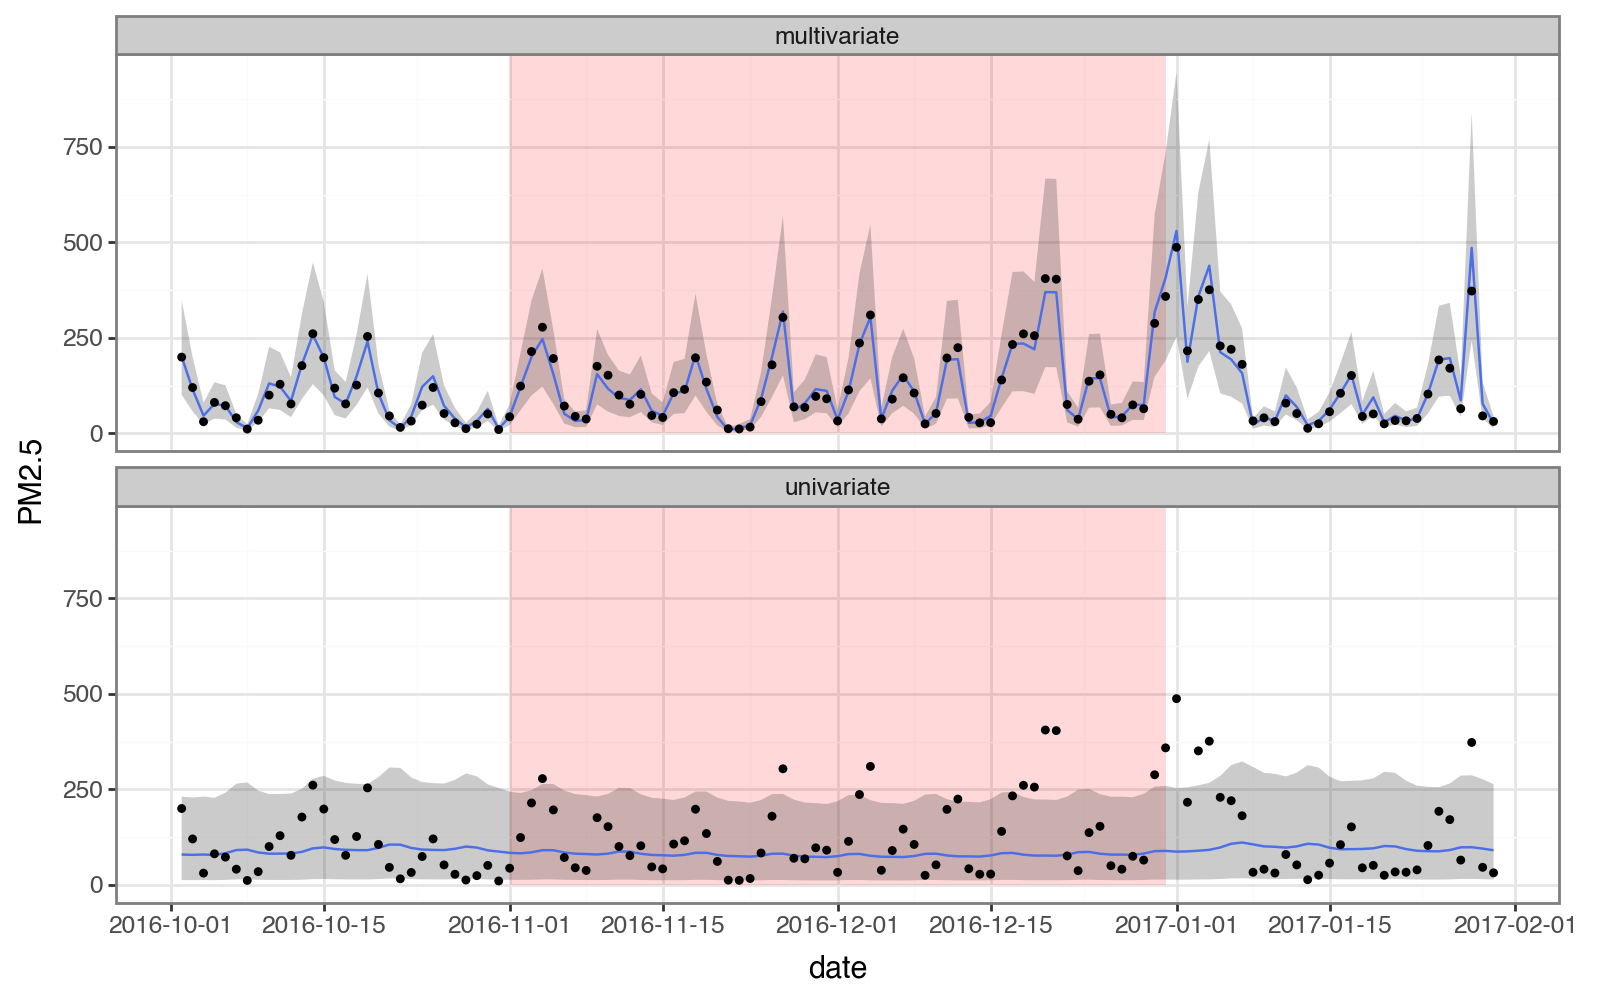

In [21]:
from plotnine import ggplot, aes, geom_line, geom_ribbon, geom_point, annotate, theme_bw, theme, ylab

(
    ggplot(
        pd.concat([df_outage_uv, df_outage_mv])
        .query("station == 'Dongsi'")
        .loc[lambda df: df['date'].between(OUTAGE_START - np.timedelta64(30, 'D'), OUTAGE_END + np.timedelta64(30, 'D'))],
        aes(x='date')
    )
    + annotate('rect', xmin=OUTAGE_START, xmax=OUTAGE_END, ymin=0, ymax=np.inf, alpha=.15, fill='red')
    + geom_ribbon(aes(ymin='lower', ymax='upper'), alpha=.25)
    + geom_line(aes(y='mean'), color='#4C6FE7')
    + geom_point(aes(y='actual'), size=.8)
    + facet_wrap('~model', ncol=1)
    + ylab('PM2.5')
    + theme_bw()
    + theme(figure_size=(8, 5))
)

During the outage (shaded), the univariate model can only forecast, while the multivariate model tracks PM2.5 closely using each day's PM10 -- cutting the error by nearly 80%. (Outside the outage, the top panel is still conditioning on PM10 alone, just for illustration.)

(Its 90% intervals are conservative here: they cover every actual value during the outage. The model assumes the relationship between PM10 and PM2.5 is equally tight all year, but it's tighter in winter, when this outage happens -- and looser in the spring, when dust storms contribute coarse particles to PM10 but not PM2.5. A seasonally-varying measure-covariance could capture that; see `Covariance` and its `predict_variance` argument.)

## Adding Predictors

In many settings we have external (a.k.a. _exogenous_) predictors we'd like to incorporate. Here we'll use four predictors corresponding to weather conditions. Of course, in a forecasting context, we run into the problem of needing to fill in values for these predictors for future dates. For an arbitrary forecast horizon this can be a complex issue; for simplicity here we'll focus on the 4-week-ahead predictions we used above, and simply lag our weather predictors by 4.

In [22]:
from torchcast.process import LinearModel

# prepare external predictors:
predictors_raw = ['TEMP', 'PRES', 'DEWP']
predictors = [p.lower() + '_lag30' for p in predictors_raw]
# standardize:
predictor_means = df_aq.query("dataset=='train'")[predictors_raw].mean()
predictor_stds = df_aq.query("dataset=='train'")[predictors_raw].std()
df_aq[predictors] = (df_aq[predictors_raw] - predictor_means) / predictor_stds
# lag:
df_aq[predictors] = df_aq.groupby('station')[predictors].shift(30, fill_value=0)

# create dataset:
dataset_pm_lm = TimeSeriesDataset.from_dataframe(
    dataframe=df_aq,
    dt_unit='D',
    y_colnames=['PM10_log10','PM2p5_log10'],
    X_colnames=predictors,
    group_colname='station', 
    time_colname='date',
)
dataset_pm_lm_train, _ = dataset_pm_lm.train_val_split(dt=SPLIT_DT)
dataset_pm_lm_train

TimeSeriesDataset(sizes=[torch.Size([12, 1088, 2]), torch.Size([12, 1088, 3])], measures=(('PM10_log10', 'PM2p5_log10'), ('temp_lag30', 'pres_lag30', 'dewp_lag30')))

In [23]:
_processes = []
for m in dataset_pm_lm.measures[0]:
    _processes.extend([
        LocalTrend(id=f'{m}_trend', measure=m),
        
        Season(
            id=f'{m}_day_in_year', 
            period=365.25, 
            dt_unit='D', 
            K=4, 
            measure=m, 
            fixed=True
        ),
        
        Season(
            id=f'{m}_day_in_week', 
            period=7, 
            dt_unit='D', 
            K=2,
            measure=m,
            fixed=True
        ),
        
        
        LinearModel(
            id=f'{m}_lm', 
            predictors=predictors, 
            measure=m
        )
    ])
kf_pm_lm = KalmanFilter(
    measures=dataset_pm_lm.measures[0], processes=_processes
)

In [24]:
# fit:
y, X = dataset_pm_lm_train.tensors
kf_pm_lm.fit(
    y,
    X=X, # if you want to supply different predictors to different processes, you can use `{process_name}__X`
    start_offsets=dataset_pm_lm_train.start_datetimes,
    n_step=5,
    every_step=False
)

For measure PM10_log10, setting initial value by setting 'PM10_log10_trend.position' to 1.9197
For measure PM2p5_log10, setting initial value by setting 'PM2p5_log10_trend.position' to 1.7518


0it [00:00, ?it/s]

KalmanFilter(
  (measure_covariance): Covariance()
  (processes): ModuleDict(
    (PM10_log10_trend): LocalTrend(id='PM10_log10_trend', measure='PM10_log10')
    (PM10_log10_day_in_year): Season(id='PM10_log10_day_in_year', measure='PM10_log10')
    (PM10_log10_day_in_week): Season(id='PM10_log10_day_in_week', measure='PM10_log10')
    (PM10_log10_lm): LinearModel(id='PM10_log10_lm', measure='PM10_log10')
    (PM2p5_log10_trend): LocalTrend(id='PM2p5_log10_trend', measure='PM2p5_log10')
    (PM2p5_log10_day_in_year): Season(id='PM2p5_log10_day_in_year', measure='PM2p5_log10')
    (PM2p5_log10_day_in_week): Season(id='PM2p5_log10_day_in_week', measure='PM2p5_log10')
    (PM2p5_log10_lm): LinearModel(id='PM2p5_log10_lm', measure='PM2p5_log10')
  )
  (process_covariance): Covariance()
  (initial_covariance): Covariance()
)

Here we show how to inspect the influence of each predictor:

Subsetting to groups: ['Wanshouxigong']


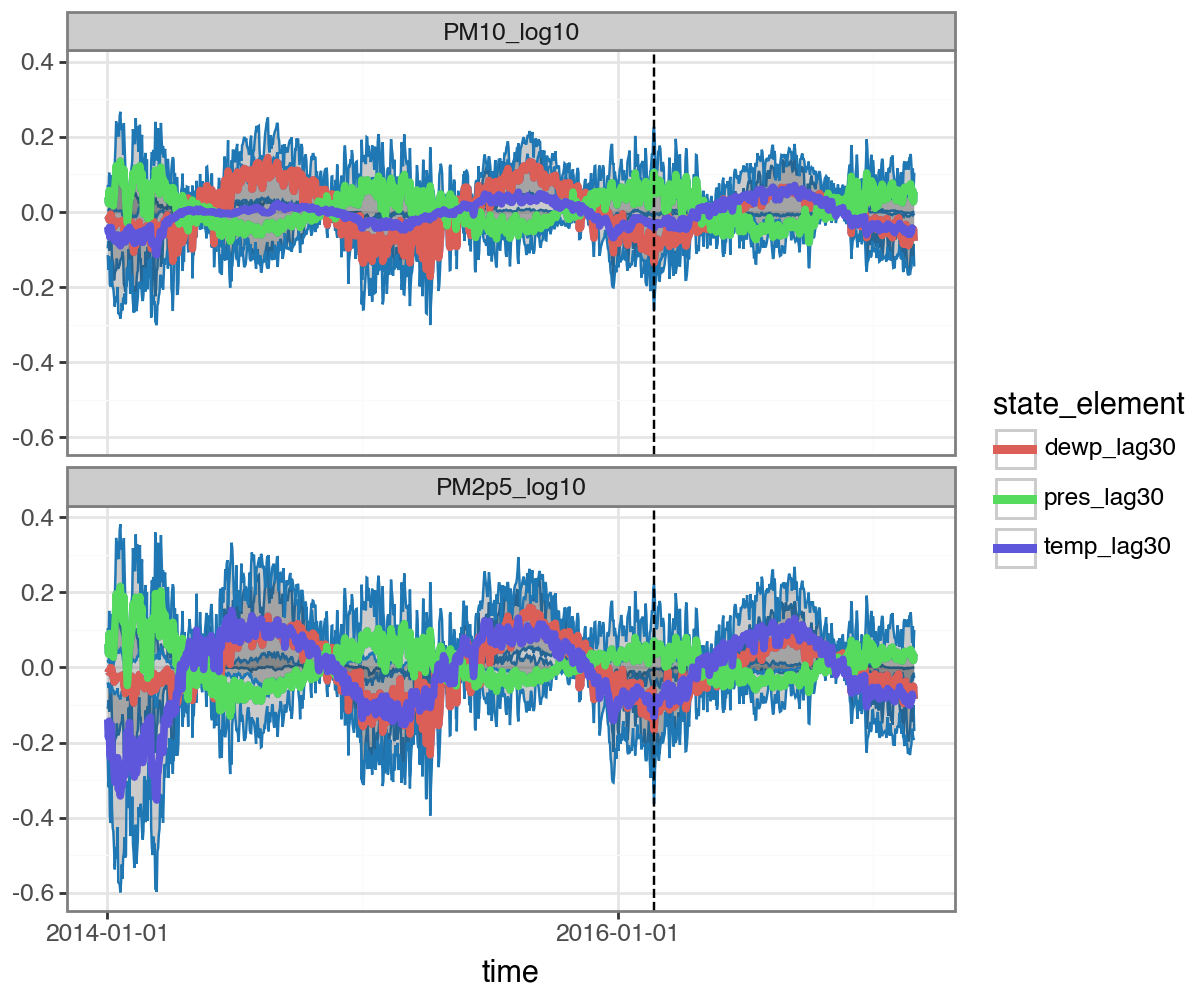

In [25]:
# inspect components:
with torch.no_grad():
    y, X = dataset_pm_lm.tensors
    one_mo_lm = kf_pm_lm(
        y,
        X=X,
        start_offsets=dataset_pm_lm.start_datetimes,
        n_step=30
    )
one_mo_lm.plot(
    one_mo_lm
    .to_dataframe(dataset_pm_lm, type='components')
    .query("process.str.contains('lm')")
    .query("time > '2014-01-01'"),
    split_dt=SPLIT_DT, 
    figure_size=(6,5)
) + facet_wrap('measure', ncol=1)

### Re-Evaluate Performance

Now let's look at the change in error from our earlier multivariate model vs. one that includes predictors.

We can't compare the forecasts, since we have a fixed lag on our predictors. But we can easily compare the expanding-window results:

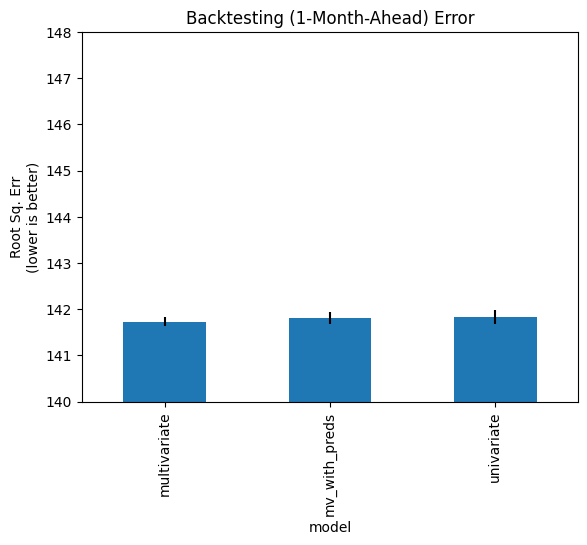

In [26]:
df_backtest1mo_err_agg2 = agg_within_group_err(
    pd.concat([
        # old ones:
        df_backtest_err1mo,
        # new one:
        one_mo_lm
        .to_dataframe(
            dataset_pm_lm,
            time_colname='date',
            group_colname='station',
            transform=LogTransform(base=10),
            derived={'PM': lambda s: s['PM10_log10'] + s['PM2p5_log10']}
        )
        .query("measure == 'PM'")
        .loc[lambda df: df['date'] > SPLIT_DT,:]
        .pipe(get_station_error)
        .assign(model='mv_with_preds')
    ])
)

df_backtest1mo_err_agg2['rmse'].plot(
    kind='bar', 
    yerr=df_backtest1mo_err_agg2['sem'] * sem_multi, 
    ylabel="Root Sq. Err\n(lower is better)", 
    title="Backtesting (1-Month-Ahead) Error",
    ylim=(140,148)
)
plt.show()

We see that the lagged predictors do not significantly impact performance.